# Quick look at the run output

In [1]:
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cmocean import cm
import warnings

# for thalweg
from salishsea_tools import visualisations as vis
import netCDF4 as nc

warnings.simplefilter('ignore')

In [37]:
# for masking the different regions of analysis
def bathmask(mydata,region):

    # region can be jdf, pug (puget sound), nsg (northern SoG), and csg (central SoG)
    # based on boxes on map
    if region == 'jdf':
        out_bath = (mydata.Bathymetry[310:360,50:100]>0).rename({'y': 'gridY','x': 'gridX'})
    
    elif region == 'pug':
        out_bath = (mydata.Bathymetry[80:130,220:270]>0).rename({'y': 'gridY','x': 'gridX'})

    elif region == 'nsg':
        out_bath = (mydata.Bathymetry[650:700,130:180]>0).rename({'y': 'gridY','x': 'gridX'})

    elif region == 'csg':
        out_bath = (mydata.Bathymetry[460:510,240:290]>0).rename({'y': 'gridY','x': 'gridX'})

    else:
        print("invalid region name")

    return out_bath


# booleans describing the different regions of analysis
def booleans(mydata,region,depth):

    if depth==50:
        depth_bool = mydata.deptht == mydata.deptht[23]
    elif depth==0:
        depth_bool = mydata.deptht == mydata.deptht[0]
    elif depth==300:
        depth_bool = mydata.deptht == mydata.deptht[35]


    # region can be jdf, pug (puget sound), nsg (northern SoG), and csg (central SoG)
    # based on boxes on map
    if region == 'jdf':
        y_bool = (mydata.y >=310) & (mydata.y <360) 
        x_bool = (mydata.x >=50) & (mydata.x<100)
    
    elif region == 'pug':
        y_bool = (mydata.y >=80) & (mydata.y <130)
        x_bool = (mydata.x >=220) & (mydata.x<270)

    elif region == 'nsg':
        y_bool = (mydata.y >=650) & (mydata.y <700)
        x_bool = (mydata.x >=130) & (mydata.x<180)

    elif region == 'csg':
        y_bool = (mydata.y >=460) & (mydata.y <510)
        x_bool = (mydata.x >=240) & (mydata.x<290)

    else:
        print("invalid region name")

    return depth_bool, y_bool, x_bool

In [23]:
# bathymetry for masking land values
bath = xr.open_dataset("/home/rbeutel/MEOPAR/grid/bathymetry_202108.nc") 

# original salishseacast
path_old = Path("/home/rbeutel/projects/def-allen/SalishSea/nowcast-green.202111/")
# note that we only have 2018 salishseacast results on fir
old =xr.open_mfdataset(sorted(path_old.glob(f"*18/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))
old19 = xr.open_mfdataset(sorted(path_old.glob(f"*jul19/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))
old20 = xr.open_mfdataset(sorted(path_old.glob(f"*jul20/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))
old21 = xr.open_mfdataset(sorted(path_old.glob(f"*jul21/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))
old22 = xr.open_mfdataset(sorted(path_old.glob(f"*jul22/SalishSea_1d_*_grid_T.nc"))).where(~np.isnan(bath.Bathymetry))

In [4]:
old.deptht.values

array([  0.5000003,   1.5000031,   2.5000114,   3.5000305,   4.5000706,
         5.5001507,   6.5003104,   7.500623 ,   8.501236 ,   9.502433 ,
        10.5047655,  11.509312 ,  12.518167 ,  13.535412 ,  14.568982 ,
        15.634288 ,  16.761173 ,  18.007135 ,  19.481785 ,  21.389978 ,
        24.100256 ,  28.229916 ,  34.685757 ,  44.517723 ,  58.484333 ,
        76.58559  ,  98.06296  , 121.866516 , 147.08946  , 173.11449  ,
       199.57304  , 226.2603   , 253.06664  , 279.93454  , 306.8342   ,
       333.75018  , 360.67453  , 387.6032   , 414.5341   , 441.4661   ],
      dtype=float32)

In [25]:
filedays = [pd.Period(day,freq='D').day_of_year for day in old.time_counter.values]
jul6day = pd.Period(np.datetime64('2018-07-04T12:00:00.000000000'),freq='D').day_of_year

In [6]:
# new files
# with bathymetry masking
# and spatial averaging
# jdf50_2018spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2018spin_primarytracers_jdf50_20180101_20181231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
# pug50_2018spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2018spin_primarytracers_pug50_20180101_20181231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
# nsg50_2018spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2018spin_primarytracers_nsg50_20180101_20181231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
# csg50_2018spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2018spin_primarytracers_cgs50_20180101_20181231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
# csgDeep_2018spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2018spin_primarytracers_cgsdeep_20180101_20181231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)

jdf50_2020spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2020spin_primarytracers_jdf50_20200101_20201231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
pug50_2020spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2020spin_primarytracers_pug50_20200101_20201231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
nsg50_2020spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2020spin_primarytracers_nsg50_20200101_20201231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
csg50_2020spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2020spin_primarytracers_cgs50_20200101_20201231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
csgDeep_2020spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2020spin_primarytracers_cgsdeep_20200101_20201231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)

jdf50_2021spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2021spin_primarytracers_jdf50_20210101_20211231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
pug50_2021spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2021spin_primarytracers_pug50_20210101_20211231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
nsg50_2021spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2021spin_primarytracers_nsg50_20210101_20211231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
csg50_2021spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2021spin_primarytracers_cgs50_20210101_20211231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)
csgDeep_2021spin = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/All_2021spin_primarytracers_cgsdeep_20210101_20211231.nc').where(bathmask(bath,'pug')).mean(dim=['depth','gridY','gridX'],skipna=True)

In [7]:
# other grid files for thalweg plots
newthal20 = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/ForThalweg/All_1d_20200101_20201231_pri_T_20200706-20200706.nc')
newthal21 = xr.open_dataset('/home/rbeutel/MEOPAR/analysis/output/ForThalweg/All_1d_20210101_20211231_pri_T_20210706-20210706.nc')
bathy = nc.Dataset("/home/rbeutel/MEOPAR/grid/bathymetry_202108.nc")
mesh = nc.Dataset('/home/rbeutel/MEOPAR/grid/mesh_mask201702.nc')
thalweg_in = '/home/rbeutel/MEOPAR/analysis/thalweg_working.txt'


## temperature

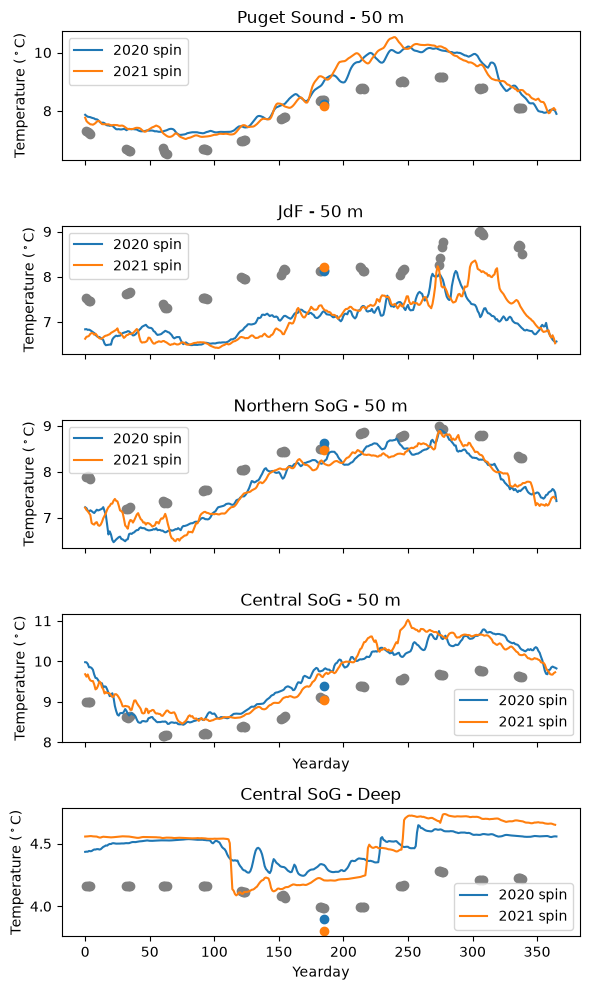

In [40]:
fig, ax = plt.subplots(5,1,figsize=(6,10))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2020spin.votemper,label='2020 spin')
ax[0].plot(pug50_2021spin.votemper,label='2021 spin')
ax[0].scatter(filedays,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[0].scatter(jul6day,np.mean(old20.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[0].scatter(jul6day,np.mean(old21.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[0].set_title('Puget Sound - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2020spin.votemper,label='2020 spin')
ax[1].plot(jdf50_2021spin.votemper,label='2021 spin')
ax[1].scatter(filedays,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[1].scatter(jul6day,np.mean(old20.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[1].scatter(jul6day,np.mean(old21.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[1].set_title('JdF - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2020spin.votemper,label='2020 spin')
ax[2].plot(nsg50_2021spin.votemper,label='2021 spin')
ax[2].scatter(filedays,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[2].scatter(jul6day,np.mean(old20.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[2].scatter(jul6day,np.mean(old21.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[2].set_title('Northern SoG - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2020spin.votemper,label='2020 spin')
ax[3].plot(csg50_2021spin.votemper,label='2021 spin')
ax[3].scatter(filedays,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[3].scatter(jul6day,np.mean(old20.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[3].scatter(jul6day,np.mean(old21.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[3].set_title('Central SoG - 50 m')
ax[3].set_xlabel('Yearday')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=300)
ax[4].plot(csgDeep_2020spin.votemper,label='2020 spin')
ax[4].plot(csgDeep_2021spin.votemper,label='2021 spin')
ax[4].scatter(filedays,np.mean(old.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[4].scatter(jul6day,np.mean(old20.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[4].scatter(jul6day,np.mean(old21.votemper[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[4].set_title('Central SoG - Deep')
ax[4].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('Temperature ($^\circ$C)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[4].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

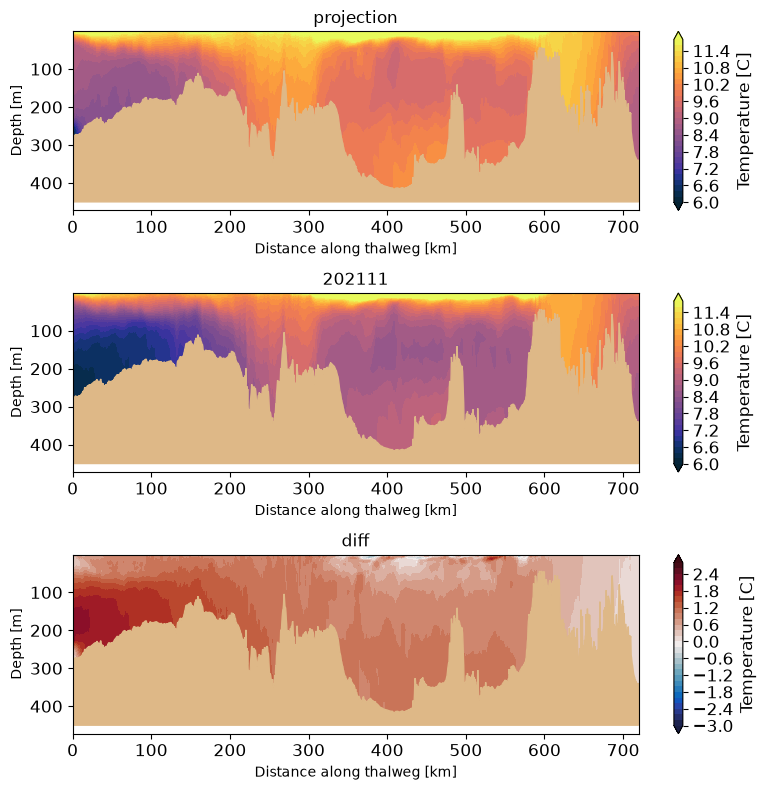

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(8,8))

temp_range = np.arange(6,12,0.2)
temp_diff = np.arange(-3,+3,0.2)

#projection
tit = 'projection'
data_to_plot = newthal20['votemper'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old20['votemper'].values[0,:,:,:] #.isel(time_counter=list(old21.time_counter.values).index(np.datetime64('2018-07-06T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
tit = 'diff'
data_to_plot = newthal20['votemper'].values[0,:,:,:] - old20['votemper'].values[0,:,:,:] #.isel(time_counter=list(old21.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=temp_diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

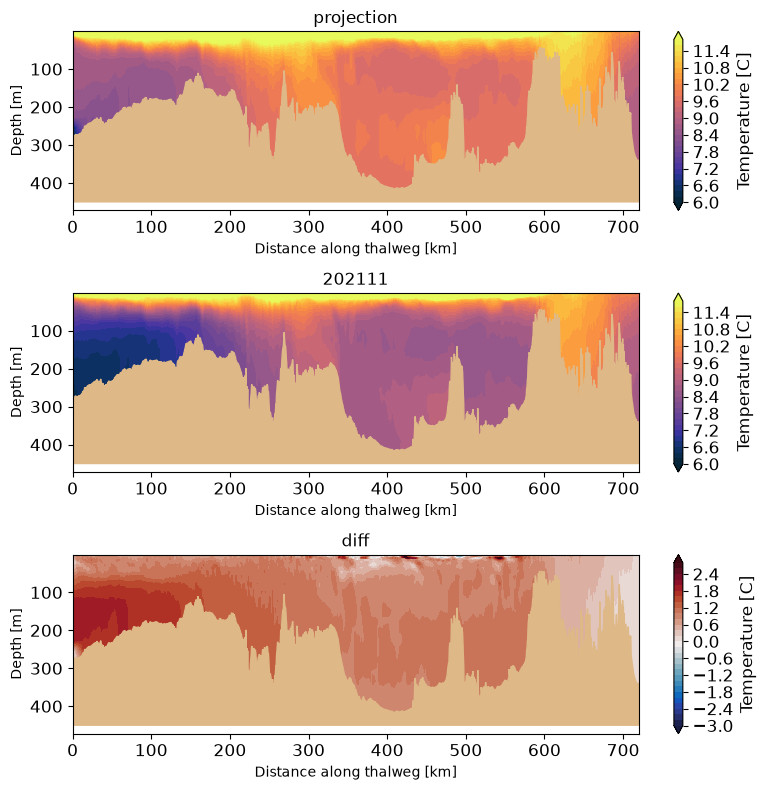

In [42]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(8,8))

temp_range = np.arange(6,12,0.2)
temp_diff = np.arange(-3,+3,0.2)

#projection
tit = 'projection'
data_to_plot = newthal21['votemper'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old21['votemper'].values[0,:,:,:] #.isel(time_counter=list(old21.time_counter.values).index(np.datetime64('2018-07-06T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=temp_range, cmap = cm.thermal, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
tit = 'diff'
data_to_plot = newthal21['votemper'].values[0,:,:,:] - old21['votemper'].values[0,:,:,:] #.isel(time_counter=list(old21.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=temp_diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Temperature [C]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

## salinity

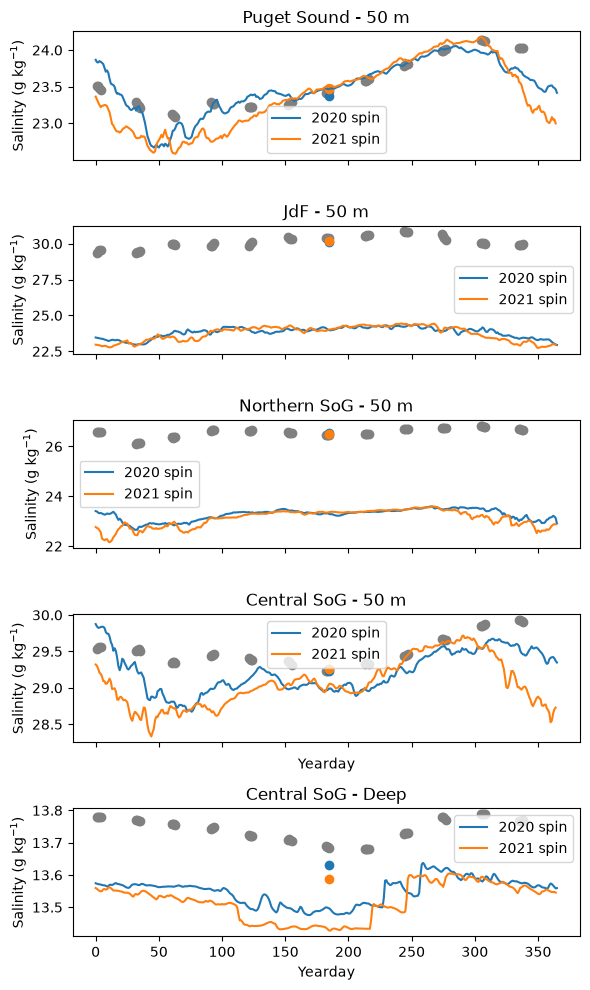

In [43]:
fig, ax = plt.subplots(5,1,figsize=(6,10))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2020spin.vosaline,label='2020 spin')
ax[0].plot(pug50_2021spin.vosaline,label='2021 spin')
ax[0].scatter(filedays,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[0].scatter(jul6day,np.mean(old20.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[0].scatter(jul6day,np.mean(old21.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[0].set_title('Puget Sound - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2020spin.vosaline,label='2020 spin')
ax[1].plot(jdf50_2021spin.vosaline,label='2021 spin')
ax[1].scatter(filedays,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[1].scatter(jul6day,np.mean(old20.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[1].scatter(jul6day,np.mean(old21.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[1].set_title('JdF - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2020spin.vosaline,label='2020 spin')
ax[2].plot(nsg50_2021spin.vosaline,label='2021 spin')
ax[2].scatter(filedays,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[2].scatter(jul6day,np.mean(old20.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[2].scatter(jul6day,np.mean(old21.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[2].set_title('Northern SoG - 50 m')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2020spin.vosaline,label='2020 spin')
ax[3].plot(csg50_2021spin.vosaline,label='2021 spin')
ax[3].scatter(filedays,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[3].scatter(jul6day,np.mean(old20.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[3].scatter(jul6day,np.mean(old21.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[3].set_title('Central SoG - 50 m')
ax[3].set_xlabel('Yearday')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=300)
ax[4].plot(csgDeep_2020spin.vosaline,label='2020 spin')
ax[4].plot(csgDeep_2021spin.vosaline,label='2021 spin')
ax[4].scatter(filedays,np.mean(old.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='grey')
ax[4].scatter(jul6day,np.mean(old20.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[4].scatter(jul6day,np.mean(old21.vosaline[:,depth_bool,y_bool,x_bool],axis=(1,2,3)))
ax[4].set_title('Central SoG - Deep')
ax[4].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('Salinity (g kg$^{-1}$)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[4].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

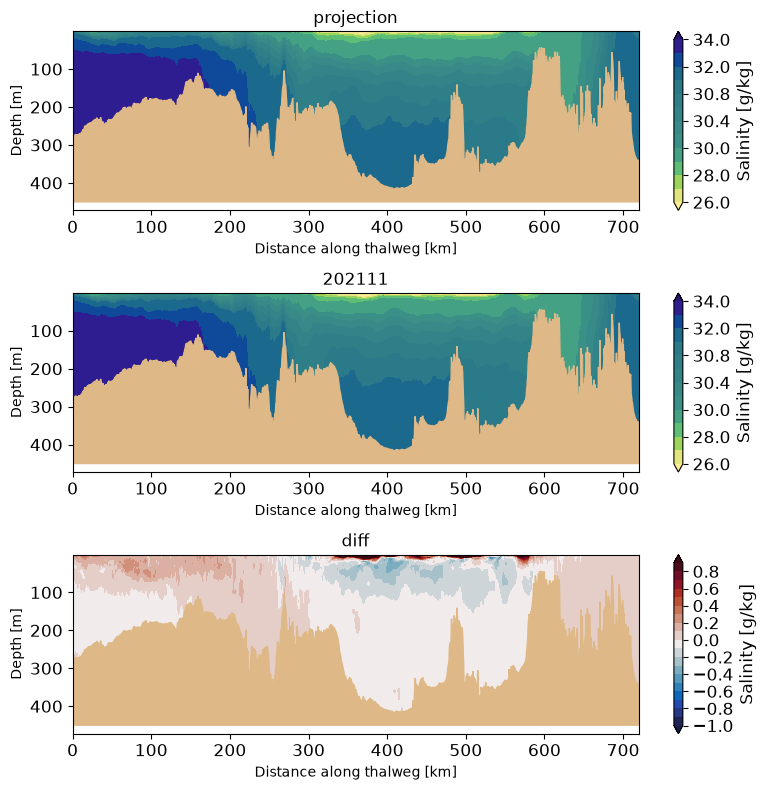

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(8,8))

#CHANGE
tit = 'projection'
data_to_plot = newthal20['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old20['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-1,1,0.1)
tit = 'diff'
data_to_plot = newthal20['vosaline'].values[0,:,:,:] - old20['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

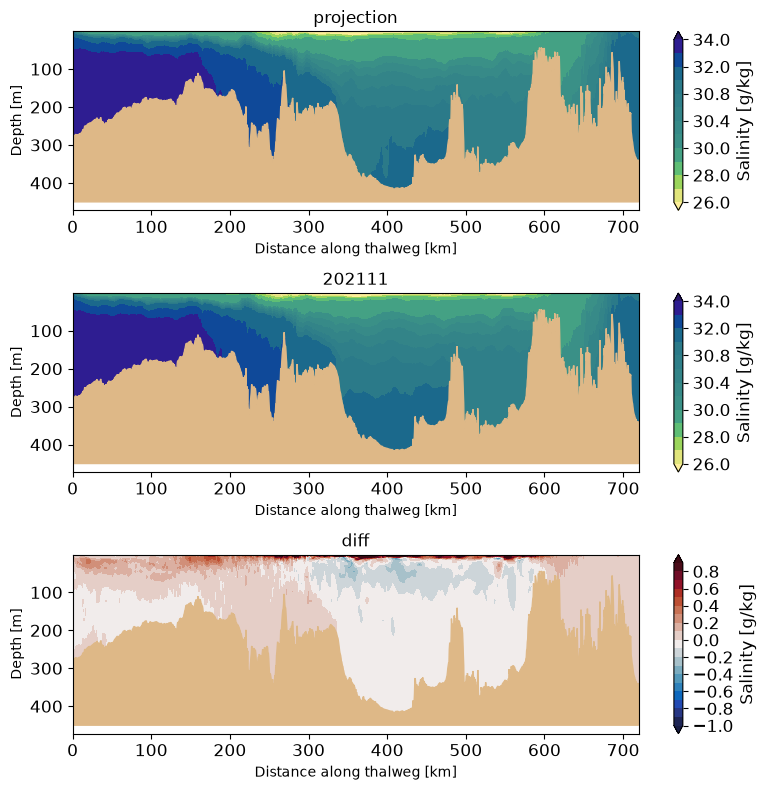

In [46]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(8,8))

#CHANGE
tit = 'projection'
data_to_plot = newthal21['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old21['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels='salinity', cmap = cm.haline_r, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-1,1,0.1)
tit = 'diff'
data_to_plot = newthal21['vosaline'].values[0,:,:,:] - old21['vosaline'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('Salinity [g/kg]', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

## oxygen

In [12]:
old =xr.open_mfdataset(sorted(path_old.glob(f"*18/SalishSea_1d_*_chem_T.nc"))).where(~np.isnan(bath.Bathymetry))

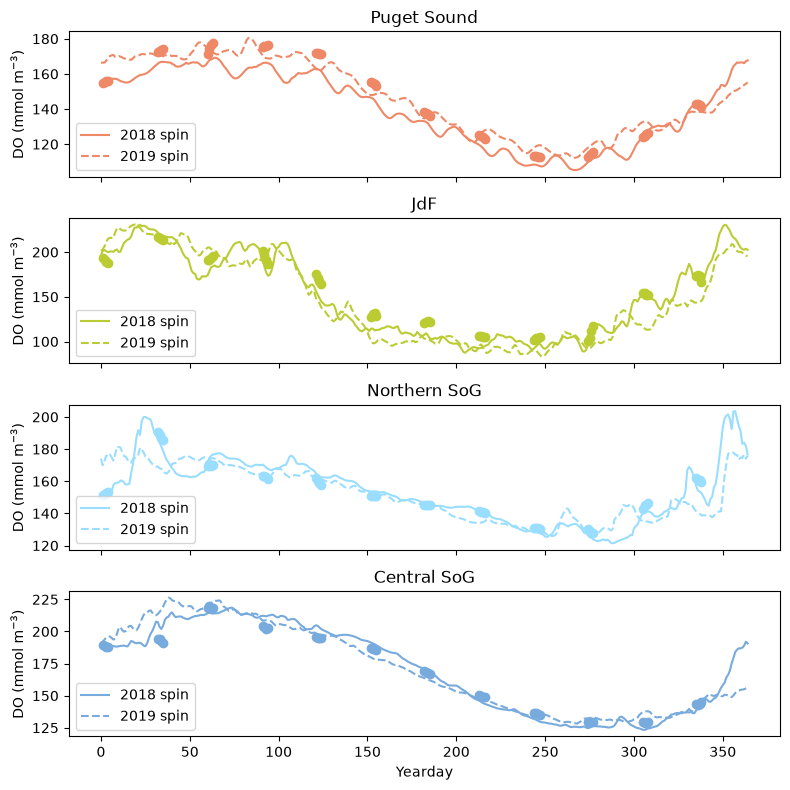

In [13]:
fig, ax = plt.subplots(4,1,figsize=(8,8))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2018spin.DO,color='#EE8866',label='2018 spin')
ax[0].plot(pug50_2019spin.DO,color='#EE8866',ls='dashed',label='2019 spin')
ax[0].scatter(filedays,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')
ax[0].set_title('Puget Sound')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2018spin.DO,color='#BBCC33',label='2018 spin')
ax[1].plot(jdf50_2019spin.DO,color='#BBCC33',ls='dashed',label='2019 spin')
ax[1].scatter(filedays,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')
ax[1].set_title('JdF')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2018spin.DO,color='#99DDFF',label='2018 spin')
ax[2].plot(nsg50_2019spin.DO,color='#99DDFF',ls='dashed',label='2019 spin')
ax[2].scatter(filedays,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')
ax[2].set_title('Northern SoG')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2018spin.DO,color='#77AADD',label='2018 spin')
ax[3].plot(csg50_2019spin.DO,color='#77AADD',ls='dashed',label='2019 spin')
ax[3].scatter(filedays,np.mean(old.dissolved_oxygen[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')
ax[3].set_title('Central SoG')
ax[3].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('DO (mmol m$^{-3}$)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[3].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

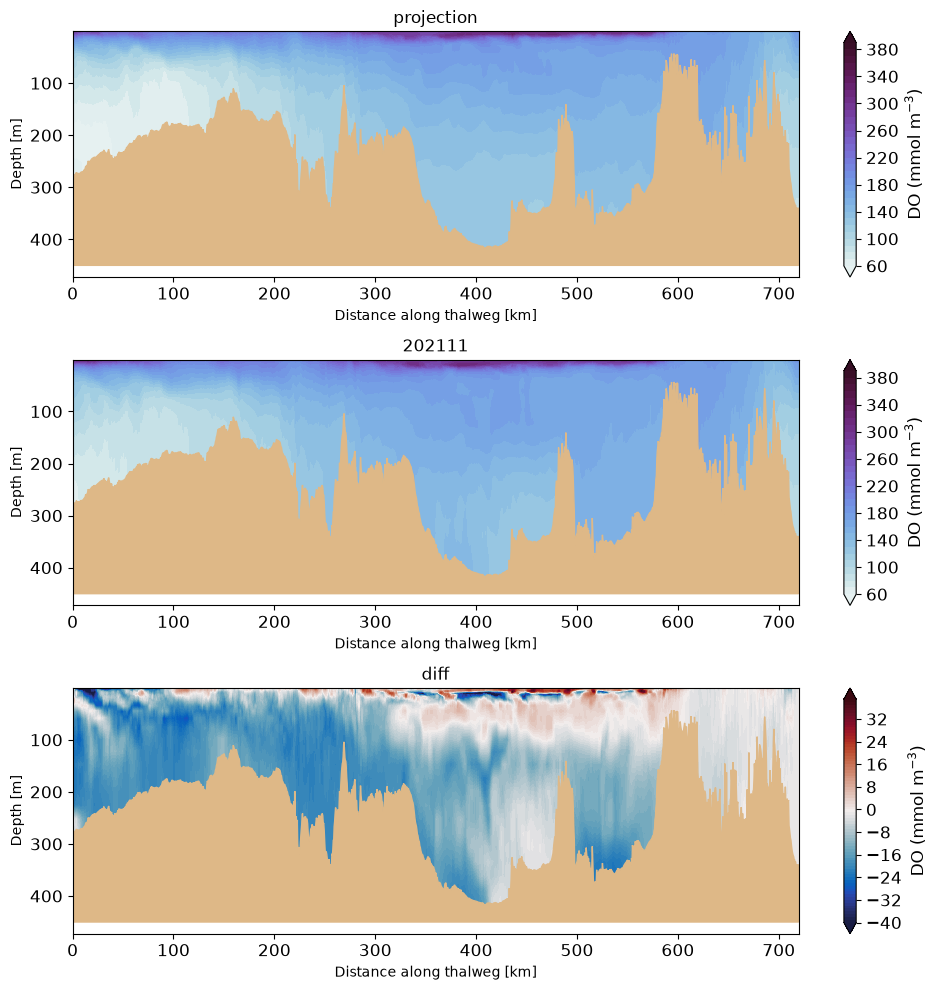

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

_range = np.arange(60,400,10)

#CHANGE
tit = 'projection'
data_to_plot = newthal['dissolved_oxygen'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('DO (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['dissolved_oxygen'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('DO (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-40,40,1)
tit = 'diff'
data_to_plot = newthal['dissolved_oxygen'].values[0,:,:,:] - old['dissolved_oxygen'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('DO (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

## DIC

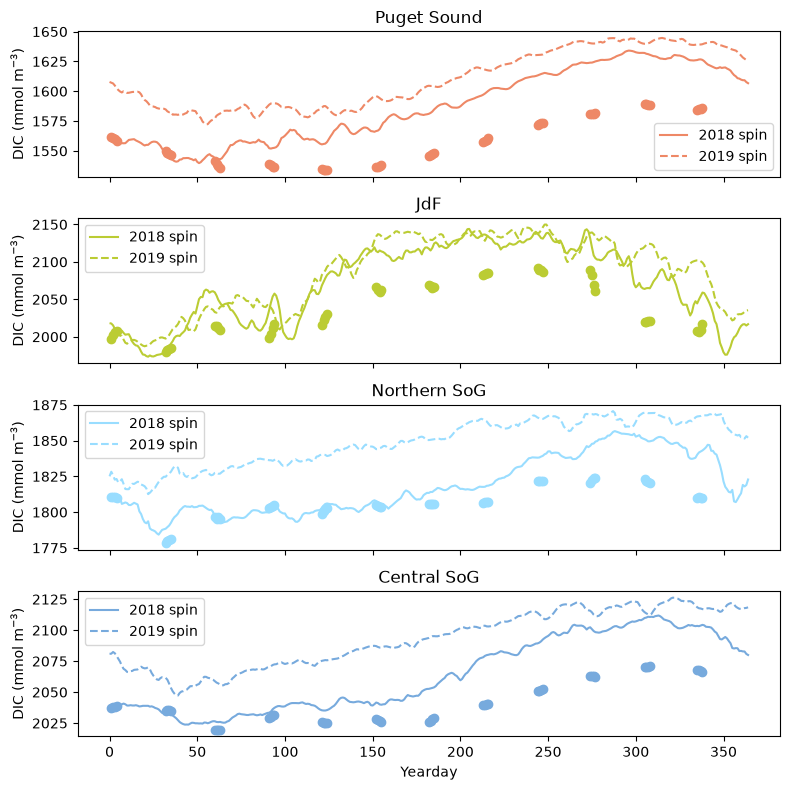

In [15]:
fig, ax = plt.subplots(4,1,figsize=(8,8))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2018spin.DIC,color='#EE8866',label='2018 spin')
ax[0].plot(pug50_2019spin.DIC,color='#EE8866',ls='dashed',label='2019 spin')
ax[0].scatter(filedays,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')
ax[0].set_title('Puget Sound')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2018spin.DIC,color='#BBCC33',label='2018 spin')
ax[1].plot(jdf50_2019spin.DIC,color='#BBCC33',ls='dashed',label='2019 spin')
ax[1].scatter(filedays,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')
ax[1].set_title('JdF')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2018spin.DIC,color='#99DDFF',label='2018 spin')
ax[2].plot(nsg50_2019spin.DIC,color='#99DDFF',ls='dashed',label='2019 spin')
ax[2].scatter(filedays,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')
ax[2].set_title('Northern SoG')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2018spin.DIC,color='#77AADD',label='2018 spin')
ax[3].plot(csg50_2019spin.DIC,color='#77AADD',ls='dashed',label='2019 spin')
ax[3].scatter(filedays,np.mean(old.dissolved_inorganic_carbon[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')
ax[3].set_title('Central SoG')
ax[3].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('DIC (mmol m$^{-3}$)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[3].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

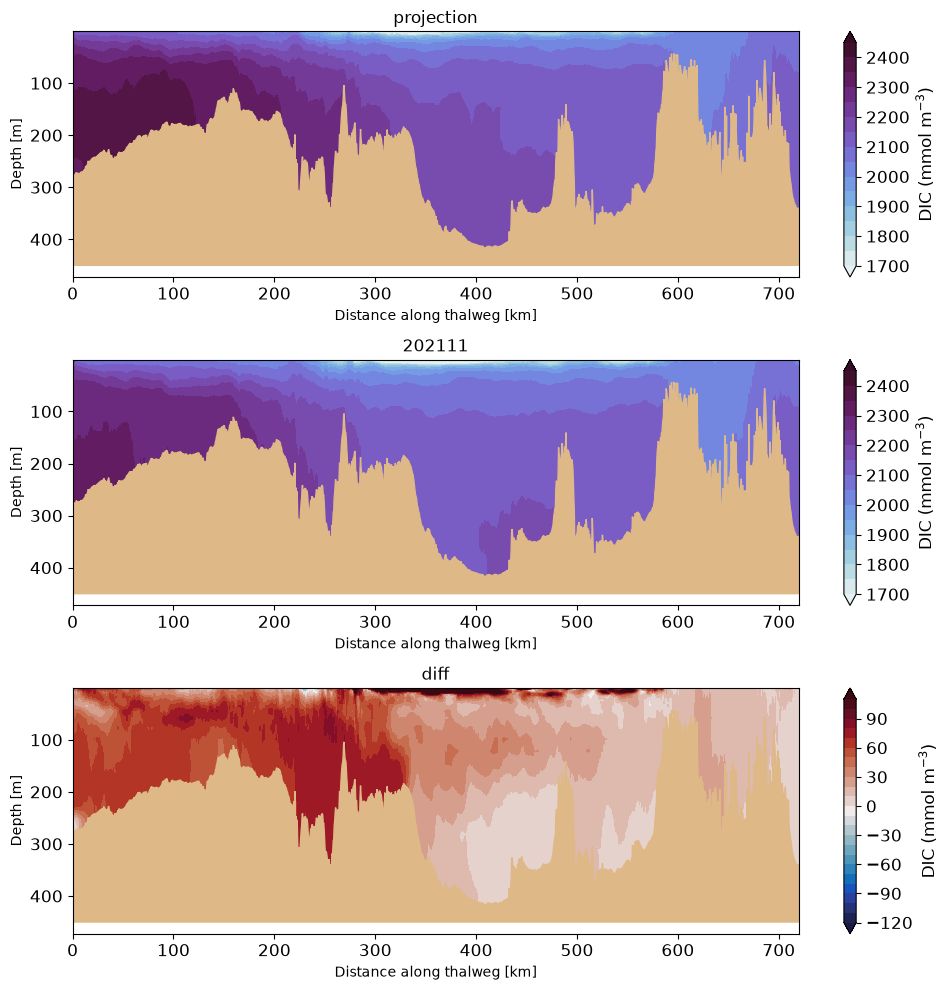

In [16]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

_range = np.arange(1700,2500,50)

#CHANGE
tit = 'projection'
data_to_plot = newthal['dissolved_inorganic_carbon'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('DIC (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['dissolved_inorganic_carbon'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('DIC (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-120,120,10)
tit = 'diff'
data_to_plot = newthal['dissolved_inorganic_carbon'].values[0,:,:,:] - old['dissolved_inorganic_carbon'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('DIC (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

## TA

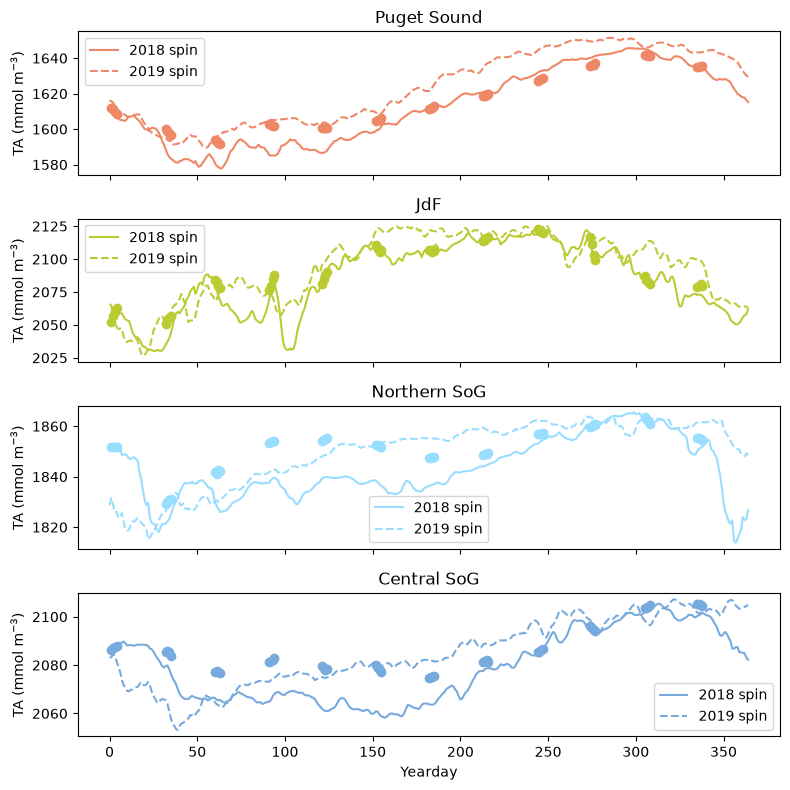

In [17]:
fig, ax = plt.subplots(4,1,figsize=(8,8))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2018spin.TA,color='#EE8866',label='2018 spin')
ax[0].plot(pug50_2019spin.TA,color='#EE8866',ls='dashed',label='2019 spin')
ax[0].scatter(filedays,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')
ax[0].set_title('Puget Sound')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2018spin.TA,color='#BBCC33',label='2018 spin')
ax[1].plot(jdf50_2019spin.TA,color='#BBCC33',ls='dashed',label='2019 spin')
ax[1].scatter(filedays,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')
ax[1].set_title('JdF')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2018spin.TA,color='#99DDFF',label='2018 spin')
ax[2].plot(nsg50_2019spin.TA,color='#99DDFF',ls='dashed',label='2019 spin')
ax[2].scatter(filedays,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')
ax[2].set_title('Northern SoG')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2018spin.TA,color='#77AADD',label='2018 spin')
ax[3].plot(csg50_2019spin.TA,color='#77AADD',ls='dashed',label='2019 spin')
ax[3].scatter(filedays,np.mean(old.total_alkalinity[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')
ax[3].set_title('Central SoG')
ax[3].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('TA (mmol m$^{-3}$)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[3].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

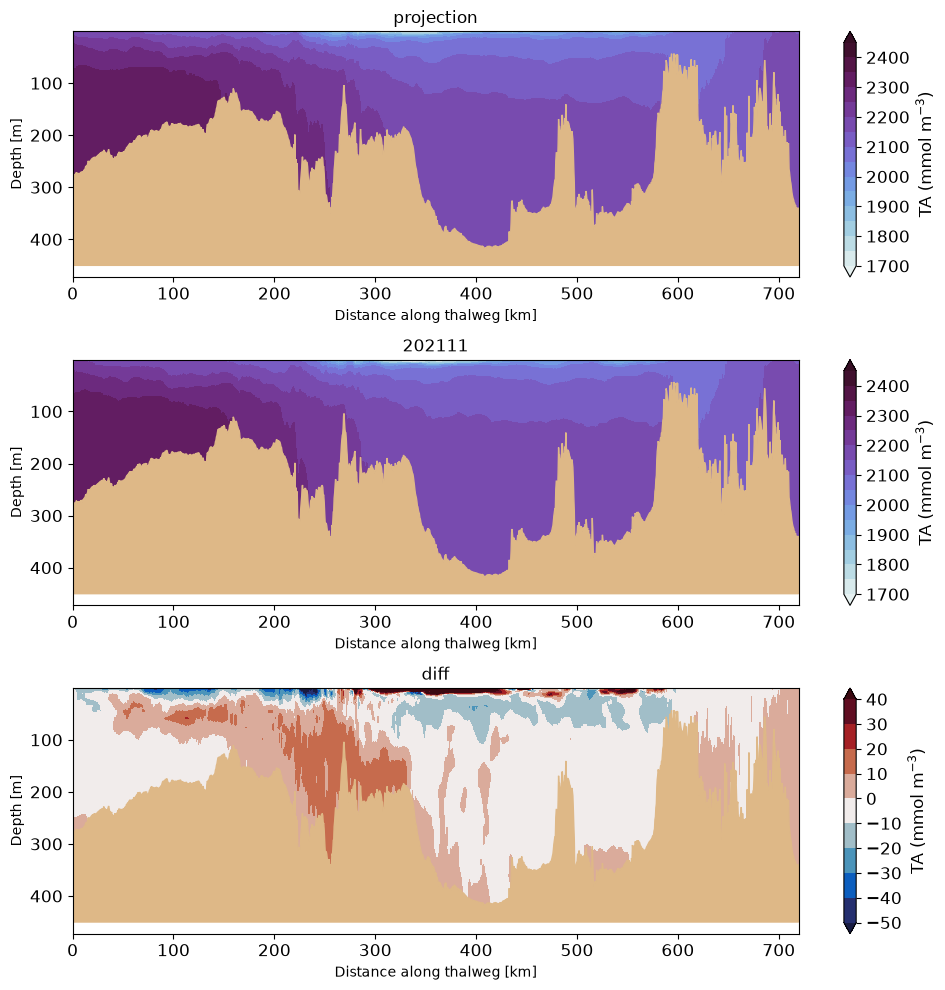

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

_range = np.arange(1700,2500,50)

#CHANGE
tit = 'projection'
data_to_plot = newthal['total_alkalinity'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('TA (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['total_alkalinity'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('TA (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-50,50,10)
tit = 'diff'
data_to_plot = newthal['total_alkalinity'].values[0,:,:,:] - old['total_alkalinity'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('TA (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()

# Nitrate

In [19]:
# original salishseacast - maybe not worth it since so little is loaded on fir
old =xr.open_mfdataset(sorted(path_old.glob(f"*18/SalishSea_1d_*_biol_T.nc"))).where(~np.isnan(bath.Bathymetry))

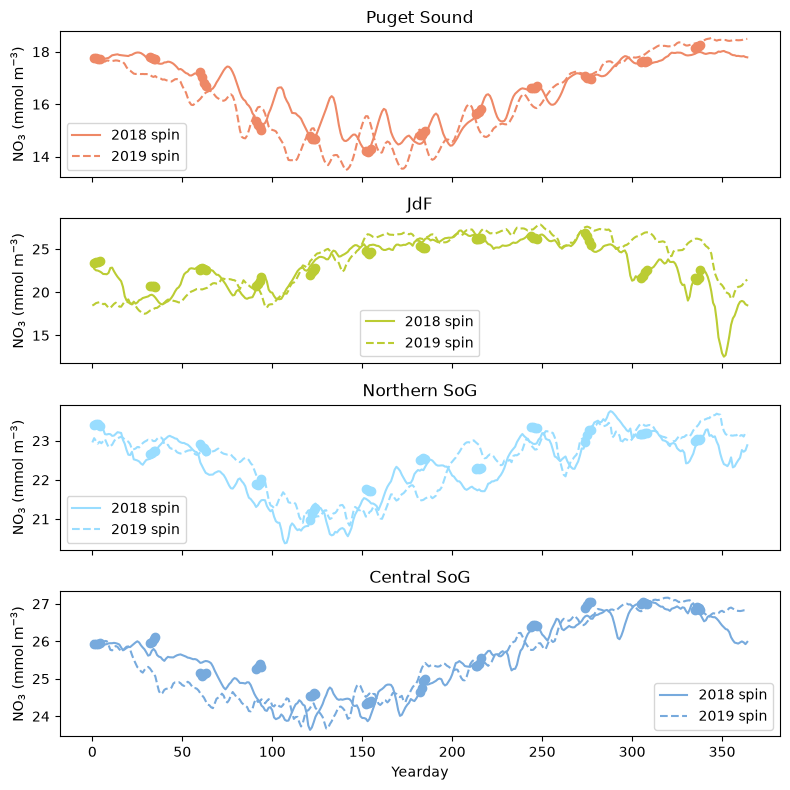

In [20]:
fig, ax = plt.subplots(4,1,figsize=(8,8))

depth_bool, y_bool, x_bool = booleans(old,'pug',depth=50)
ax[0].plot(pug50_2018spin.NO3,color='#EE8866',label='2018 spin')
ax[0].plot(pug50_2019spin.NO3,color='#EE8866',ls='dashed',label='2019 spin')
ax[0].scatter(filedays,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#EE8866')
ax[0].set_title('Puget Sound')

depth_bool, y_bool, x_bool = booleans(old,'jdf',depth=50)
ax[1].plot(jdf50_2018spin.NO3,color='#BBCC33',label='2018 spin')
ax[1].plot(jdf50_2019spin.NO3,color='#BBCC33',ls='dashed',label='2019 spin')
ax[1].scatter(filedays,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#BBCC33')
ax[1].set_title('JdF')

depth_bool, y_bool, x_bool = booleans(old,'nsg',depth=50)
ax[2].plot(nsg50_2018spin.NO3,color='#99DDFF',label='2018 spin')
ax[2].plot(nsg50_2019spin.NO3,color='#99DDFF',ls='dashed',label='2019 spin')
ax[2].scatter(filedays,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#99DDFF')
ax[2].set_title('Northern SoG')

depth_bool, y_bool, x_bool = booleans(old,'csg',depth=50)
ax[3].plot(csg50_2018spin.NO3,color='#77AADD',label='2018 spin')
ax[3].plot(csg50_2019spin.NO3,color='#77AADD',ls='dashed',label='2019 spin')
ax[3].scatter(filedays,np.mean(old.nitrate[:,depth_bool,y_bool,x_bool],axis=(1,2,3)),color='#77AADD')
ax[3].set_title('Central SoG')
ax[3].set_xlabel('Yearday')

for axs in ax:
    axs.set_ylabel('NO$_3$ (mmol m$^{-3}$)')
    axs.legend()
    axs.set_xticks(np.arange(0,365,50))
    axs.set_xticklabels('')
ax[3].set_xticklabels(np.arange(0,365,50))

plt.tight_layout()

Text(0.5, 1.0, '202111')

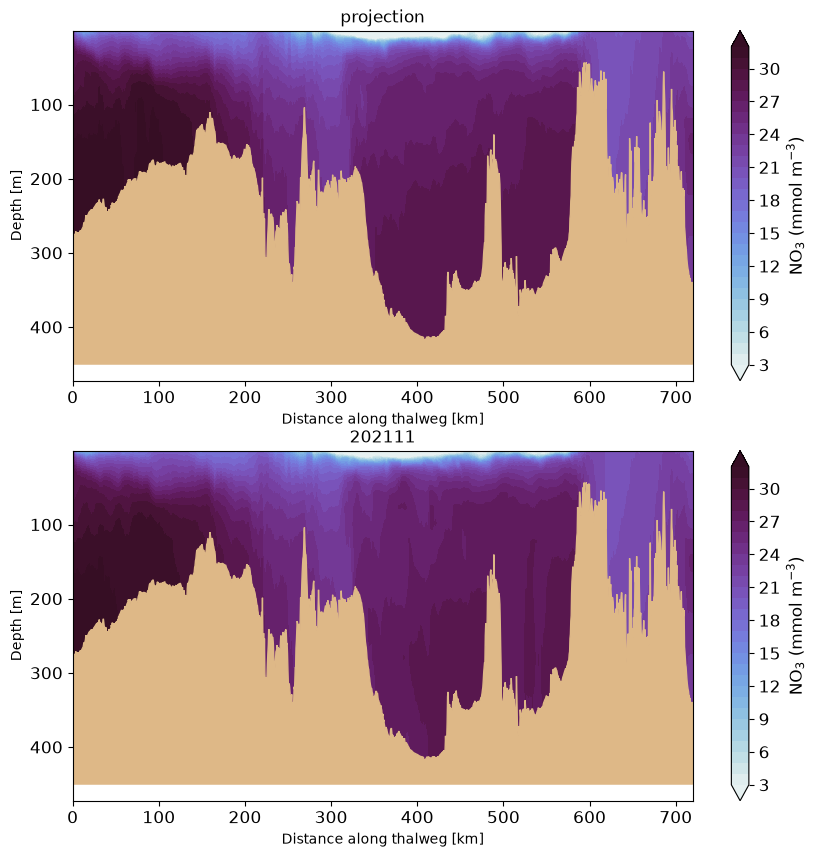

In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(10,10))

_range = np.arange(3,33,1)

#CHANGE
tit = 'projection'
data_to_plot = newthal['total_alkalinity'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('NO$_3$ (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['nitrate'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('NO$_3$ (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

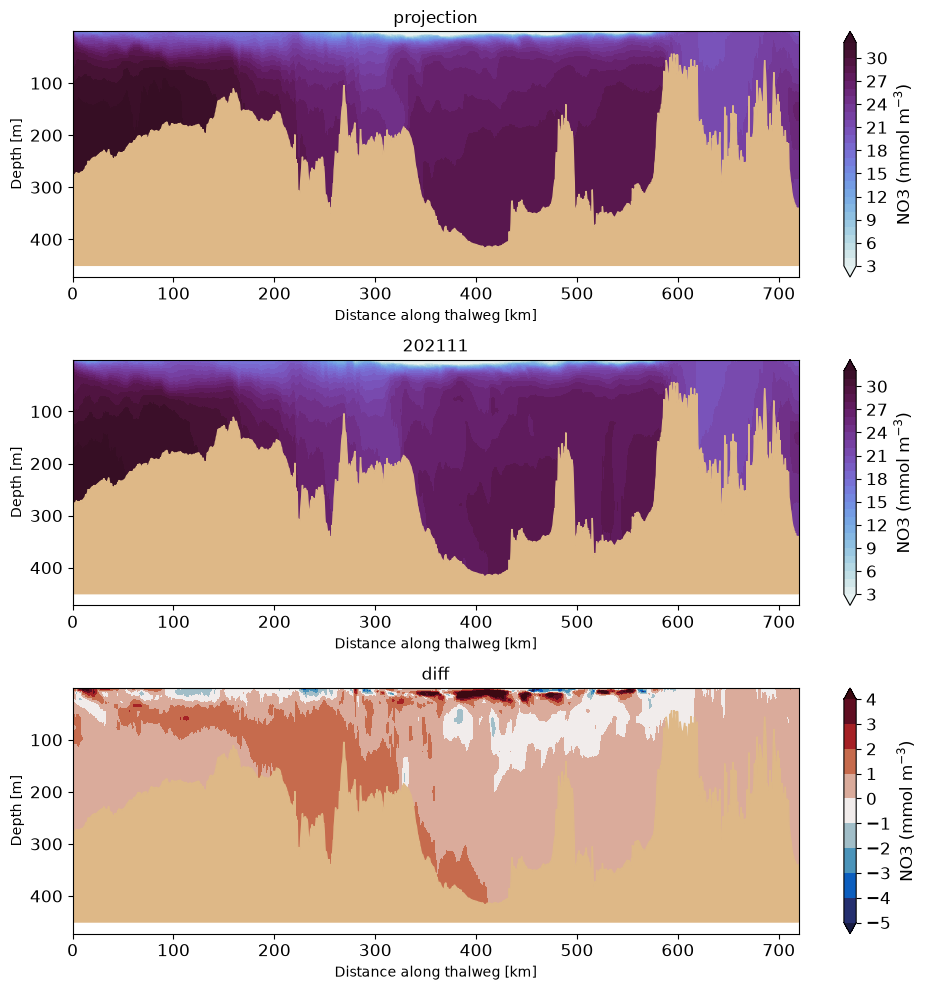

In [22]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10))

_range = np.arange(3,33,1)

#CHANGE
tit = 'projection'
data_to_plot = newthal['nitrate'].values[0,:,:,:]

cbar = vis.contour_thalweg(ax1, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('NO3 (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title(tit)

#original
tit = '202111'

data_to_plot = old['nitrate'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax2, data_to_plot, bathy, mesh, clevels=_range, cmap = cm.dense, thalweg_file=thalweg_in)
cbar.set_label('NO3 (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title(tit)

#change
diff = np.arange(-5,5,1)
tit = 'diff'
data_to_plot = newthal['nitrate'].values[0,:,:,:] - old['nitrate'].isel(time_counter=list(old.time_counter.values).index(np.datetime64('2018-07-04T12:00:00.000000000'))).values

cbar = vis.contour_thalweg(ax3, data_to_plot, bathy, mesh, clevels=diff, cmap = cm.balance, thalweg_file=thalweg_in)
cbar.set_label('NO3 (mmol m$^{-3}$)', fontsize = 12)
cbar.ax.tick_params(labelsize=12) 
ax3.tick_params(axis='both', which='major', labelsize=12)
ax3.set_title(tit)

plt.tight_layout()